# Multi-Pair Results: MNIST and Fashion-MNIST

This notebook runs a fixed-hyperparameter diagnostic benchmark across multiple binary pairs.

Purpose for the meeting:

- compare Raw SVM, Separate Dictionary + SVM, and Joint Dictionary + SVM across several pairs;
- inspect whether the joint method behaves consistently across task difficulty;
- visualize accuracy, overfitting gap, margin violation, reconstruction, and sparsity;
- avoid per-pair hyperparameter tuning for now, so the comparison remains simple and fast to explain.

Important: these are not final tuned results. They are diagnostic results under one fixed configuration.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import math
import numpy as np
import matplotlib.pyplot as plt

from src.config import default_hyperparams, mnist_task_suite, fashion_task_suite
from src.data import load_task
from src.init import initialize_params
from src.solver import fit_joint_pg
from src.metrics import infer_codes_with_dictionary
from src.experiments import (
    run_task_suite,
    flatten_comparison_rows,
    summarize_method_aggregate,
    format_method_aggregate_summary,
)

from src.explainability import (
    margin_diagnostics,
    select_representative_indices,
    sample_explanation,
    format_sample_explanation,
    plot_margin_distribution,
    svm_margin_projection,
    plot_svm_margin_projection,
    plot_sample_explanation,
)


## Fixed Hyperparameters

For this diagnostic benchmark, all pairs use the same hyperparameters.

The baseline and joint models share representation/classifier controls where possible:

- `dictionary_size`, `mu`, `gamma`, `max_iter`, and solver settings are common;
- `rho`, `eta`, and initialization scales are joint-specific;
- no validation-based tuning is performed in this notebook.


In [2]:
baseline_hyper = default_hyperparams()
joint_hyper = default_hyperparams()

# Shared controls for dictionary capacity, sparsity, classifier regularization, and budget.
for hyper in (baseline_hyper, joint_hyper):
    hyper.dictionary_size = 48
    hyper.mu = 0.5
    hyper.gamma = 10
    hyper.max_iter = 100
    hyper.random_state = 42

# Joint-only controls.
joint_hyper.rho = 10
joint_hyper.eta = 10
joint_hyper.init_code_scale = 5e-3
joint_hyper.init_classifier_scale = 5e-3

print('baseline_hyper:', baseline_hyper)
print('joint_hyper:', joint_hyper)


baseline_hyper: HyperParams(dictionary_size=48, mu=0.5, rho=1.0, gamma=10, eta=1.0, init_code_scale=0.001, init_classifier_scale=0.001, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=42, code_correction_every=0, code_correction_max_iter=50, code_correction_blend=1.0, code_correction_update_u=True)
joint_hyper: HyperParams(dictionary_size=48, mu=0.5, rho=10, gamma=10, eta=10, init_code_scale=0.005, init_classifier_scale=0.005, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=42, code_correction_every=0, code_correction_max_iter=50, code_correction_blend=1.0, code_correction_update_u=True)


## Task Suite

The suite includes four MNIST digit pairs and four Fashion-MNIST pairs.

The goal is not to cherry-pick a single favorable pair, but to observe whether the joint method is stable across easier and harder binary tasks.

In [3]:
tasks = list(mnist_task_suite()) + list(fashion_task_suite())

for task in tasks:
    print(f'{task.dataset:13s} | {task.name:20s} | {task.label_description()}')


mnist         | 3 vs 8               | 3 vs 8
mnist         | 4 vs 9               | 4 vs 9
mnist         | 1 vs 7               | 1 vs 7
mnist         | 5 vs 8               | 5 vs 8
fashion_mnist | T-shirt vs Shirt     | 0 vs 6
fashion_mnist | Pullover vs Coat     | 2 vs 4
fashion_mnist | Dress vs Coat        | 3 vs 4
fashion_mnist | Sandal vs Sneaker    | 5 vs 7


## Run Benchmark

This cell runs all methods on all pairs. It may take a while because each pair trains Raw SVM, Separate Dictionary + SVM, and Joint Dictionary + SVM.

In [4]:
task_results = run_task_suite(tasks, baseline_hyper, joint_hyper)
comparison_rows = flatten_comparison_rows(task_results)

task_meta = {result['task']['name']: result['task'] for result in task_results}
for row in comparison_rows:
    meta = task_meta[row['task']]
    row['dataset'] = meta['dataset']
    row['pair'] = meta['name']
    row['train_test_gap'] = row['train_accuracy'] - row['test_accuracy']

print(f'completed tasks: {len(task_results)}')
print(f'comparison rows: {len(comparison_rows)}')


completed tasks: 8
comparison rows: 24


## Table Helpers

In [5]:
def _format_value(value, digits=4):
    if value is None:
        return ''
    if isinstance(value, float):
        if not math.isfinite(value):
            return ''
        return f'{value:.{digits}g}'
    return str(value)


def print_table(rows, columns, digits=4, max_rows=None):
    selected = rows if max_rows is None else rows[:max_rows]
    print(' | '.join(columns))
    print(' | '.join(['---'] * len(columns)))
    for row in selected:
        print(' | '.join(_format_value(row.get(col), digits=digits) for col in columns))


def aggregate_by_dataset_method(rows):
    grouped = {}
    for row in rows:
        key = (row['dataset'], row['method'])
        grouped.setdefault(key, []).append(row)

    output = []
    metrics = [
        'test_accuracy',
        'train_test_gap',
        'test_score_gap',
        'test_violation_rate',
        'test_reconstruction_error',
        'test_code_sparsity_1em3',
    ]
    for (dataset, method), members in sorted(grouped.items()):
        summary = {'dataset': dataset, 'method': method, 'tasks': len(members)}
        for metric in metrics:
            values = np.array([member.get(metric, np.nan) for member in members], dtype=np.float64)
            finite = values[np.isfinite(values)]
            summary[f'{metric}_mean'] = float(finite.mean()) if finite.size else float('nan')
            summary[f'{metric}_std'] = float(finite.std()) if finite.size else float('nan')
        output.append(summary)
    return output


## Task-Level Results

In [6]:
task_columns = [
    'dataset',
    'pair',
    'method',
    'train_accuracy',
    'val_accuracy',
    'test_accuracy',
    'train_test_gap',
    'test_score_gap',
    'test_violation_rate',
    'test_reconstruction_error',
    'test_code_sparsity_1em3',
]

print_table(comparison_rows, task_columns, digits=4)


dataset | pair | method | train_accuracy | val_accuracy | test_accuracy | train_test_gap | test_score_gap | test_violation_rate | test_reconstruction_error | test_code_sparsity_1em3
--- | --- | --- | --- | --- | --- | --- | --- | --- | --- | ---
mnist | 3 vs 8 | Raw SVM | 0.997 | 0.975 | 0.96 | 0.037 | 3.517 | 0.22 |  | 
mnist | 3 vs 8 | Separate Dict + SVM | 0.963 | 0.97 | 0.95 | 0.013 | 1.377 | 0.815 | 73.89 | 0.1496
mnist | 3 vs 8 | Joint Dict + SVM | 1 | 0.97 | 0.9425 | 0.0575 | 1.641 | 0.65 | 82.38 | 0.1733
mnist | 4 vs 9 | Raw SVM | 0.993 | 0.955 | 0.9375 | 0.0555 | 3.113 | 0.285 |  | 
mnist | 4 vs 9 | Separate Dict + SVM | 0.955 | 0.955 | 0.94 | 0.015 | 1.281 | 0.8525 | 57.58 | 0.1761
mnist | 4 vs 9 | Joint Dict + SVM | 1 | 0.945 | 0.93 | 0.07 | 1.476 | 0.67 | 71.62 | 0.2319
mnist | 1 vs 7 | Raw SVM | 1 | 0.995 | 0.995 | 0.005 | 4.108 | 0.0675 |  | 
mnist | 1 vs 7 | Separate Dict + SVM | 0.985 | 0.98 | 0.9875 | -0.0025 | 1.516 | 0.9025 | 56.84 | 0.3872
mnist | 1 vs 7 | Joint Dic

## Aggregate Results by Dataset and Method

In [7]:
aggregate_rows = aggregate_by_dataset_method(comparison_rows)
aggregate_columns = [
    'dataset',
    'method',
    'tasks',
    'test_accuracy_mean',
    'test_accuracy_std',
    'train_test_gap_mean',
    'test_score_gap_mean',
    'test_violation_rate_mean',
    'test_reconstruction_error_mean',
    'test_code_sparsity_1em3_mean',
]

print_table(aggregate_rows, aggregate_columns, digits=4)


dataset | method | tasks | test_accuracy_mean | test_accuracy_std | train_test_gap_mean | test_score_gap_mean | test_violation_rate_mean | test_reconstruction_error_mean | test_code_sparsity_1em3_mean
--- | --- | --- | --- | --- | --- | --- | --- | --- | ---
fashion_mnist | Joint Dict + SVM | 4 | 0.8906 | 0.05054 | 0.1094 | 1.38 | 0.7019 | 68.4 | 0.2424
fashion_mnist | Raw SVM | 4 | 0.8919 | 0.05925 | 0.08338 | 2.684 | 0.3981 |  | 
fashion_mnist | Separate Dict + SVM | 4 | 0.8906 | 0.04922 | 0.004125 | 1.008 | 0.9125 | 65.09 | 0.2211
mnist | Joint Dict + SVM | 4 | 0.9488 | 0.02281 | 0.05125 | 1.582 | 0.6731 | 75.33 | 0.2469
mnist | Raw SVM | 4 | 0.9594 | 0.02211 | 0.03663 | 3.438 | 0.215 |  | 
mnist | Separate Dict + SVM | 4 | 0.955 | 0.01912 | 0.01 | 1.354 | 0.8575 | 64.76 | 0.2152


## Plot Helpers

In [8]:
METHOD_ORDER = ['Raw SVM', 'Separate Dict + SVM', 'Joint Dict + SVM']
COLORS = {
    'Raw SVM': '#4c78a8',
    'Separate Dict + SVM': '#f58518',
    'Joint Dict + SVM': '#54a24b',
}


def _task_label(row):
    prefix = 'MNIST' if row['dataset'] == 'mnist' else 'Fashion'
    return f'{prefix}: {row["pair"]}'


def plot_metric_by_task(rows, metric, title, ylabel):
    labels = []
    for row in rows:
        label = _task_label(row)
        if label not in labels:
            labels.append(label)

    x = np.arange(len(labels), dtype=np.float64)
    width = 0.24
    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.2), 4.8))

    for idx, method in enumerate(METHOD_ORDER):
        values = []
        for label in labels:
            match = next((row for row in rows if _task_label(row) == label and row['method'] == method), None)
            value = float('nan') if match is None else float(match.get(metric, float('nan')))
            values.append(value)
        ax.bar(x + (idx - 1) * width, values, width=width, label=method, color=COLORS[method])

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(axis='y', alpha=0.25)
    ax.legend()
    fig.tight_layout()
    return fig, ax


def plot_tradeoff(rows, x_metric, y_metric, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(7, 5))
    for method in METHOD_ORDER:
        method_rows = [row for row in rows if row['method'] == method]
        xs = np.array([row.get(x_metric, np.nan) for row in method_rows], dtype=np.float64)
        ys = np.array([row.get(y_metric, np.nan) for row in method_rows], dtype=np.float64)
        mask = np.isfinite(xs) & np.isfinite(ys)
        if np.any(mask):
            ax.scatter(xs[mask], ys[mask], label=method, color=COLORS[method], s=55, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    return fig, ax


## Visualizations

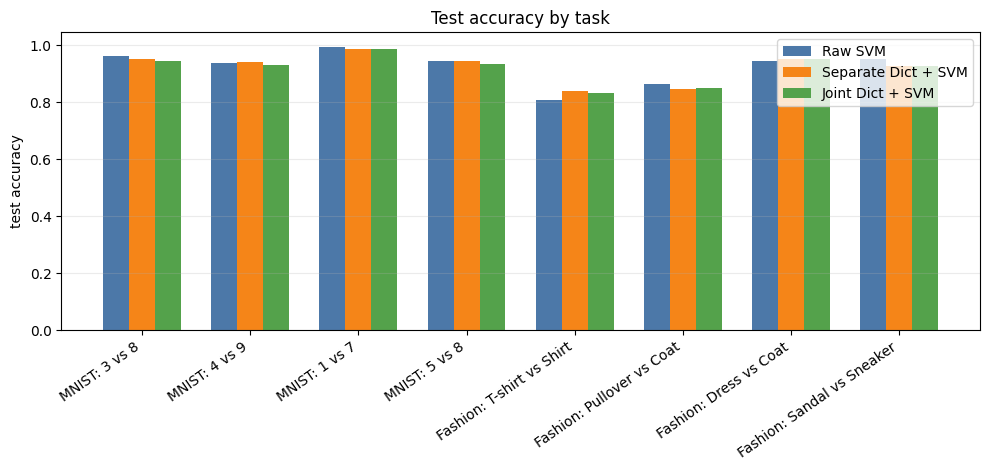

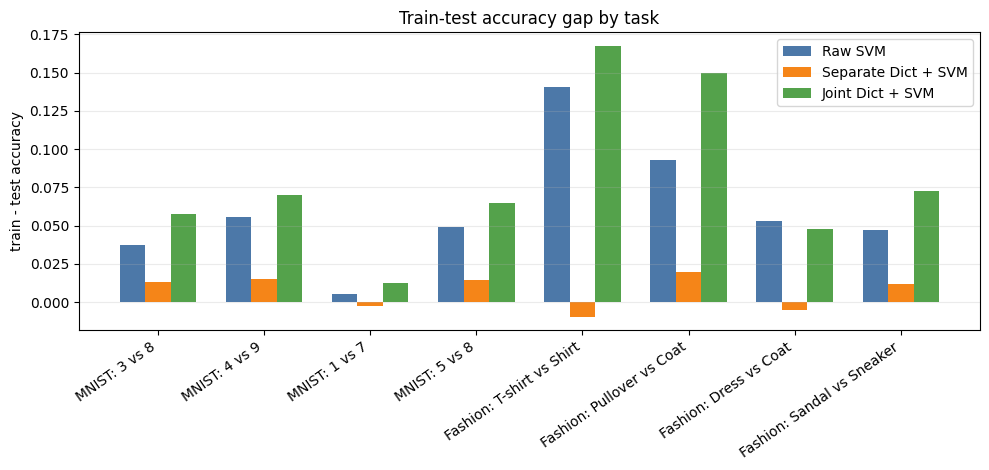

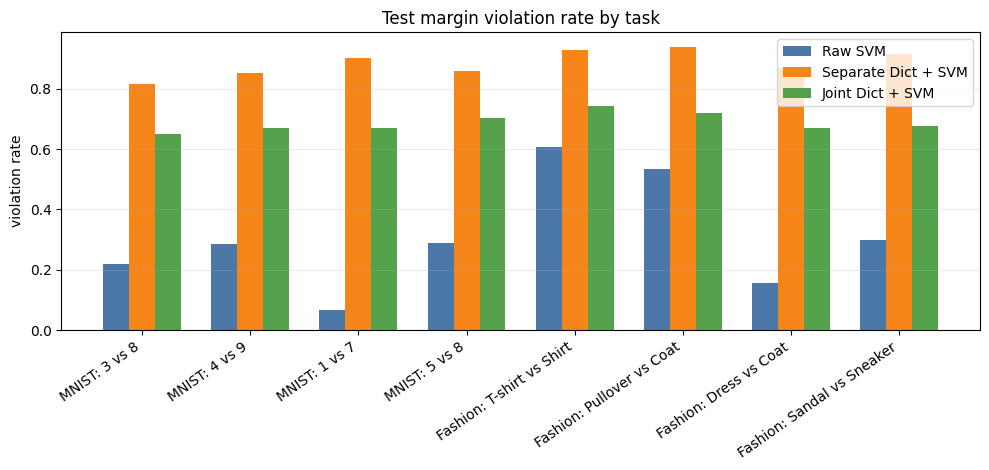

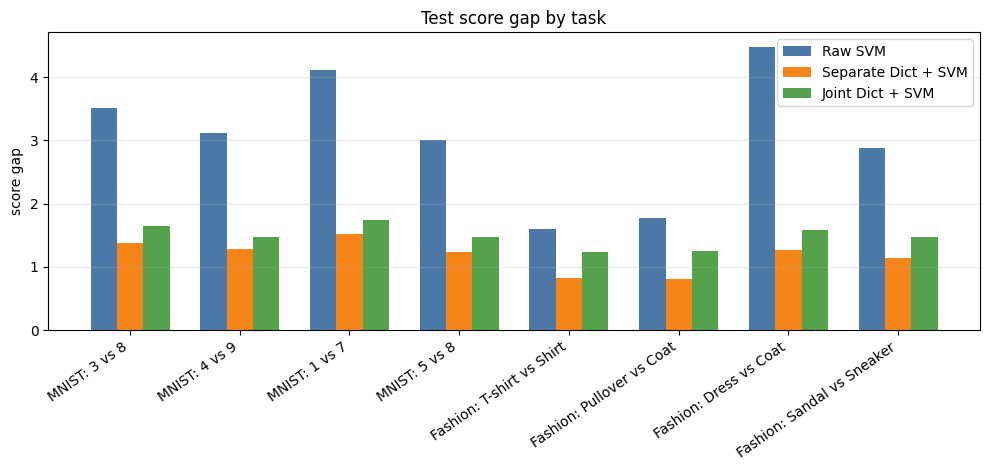

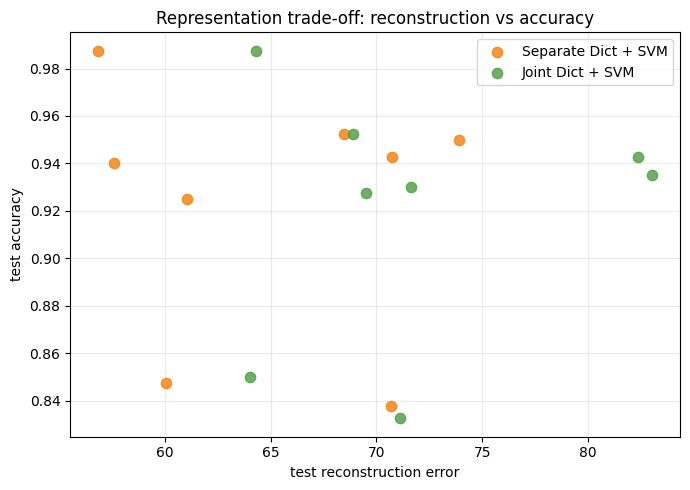

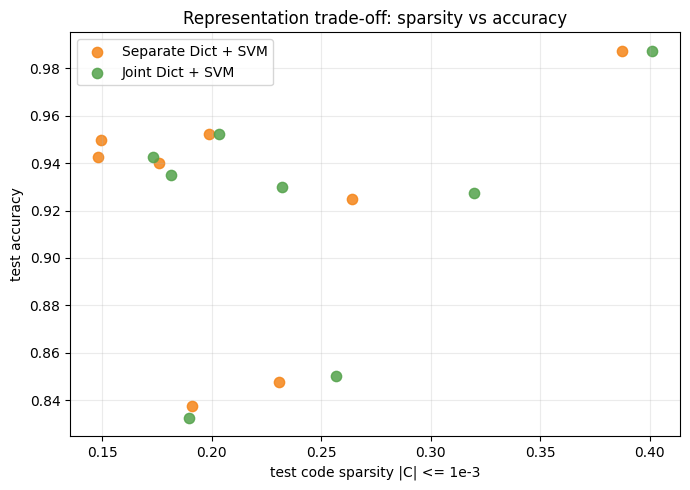

In [9]:
plot_metric_by_task(comparison_rows, 'test_accuracy', 'Test accuracy by task', 'test accuracy')
plot_metric_by_task(comparison_rows, 'train_test_gap', 'Train-test accuracy gap by task', 'train - test accuracy')
plot_metric_by_task(comparison_rows, 'test_violation_rate', 'Test margin violation rate by task', 'violation rate')
plot_metric_by_task(comparison_rows, 'test_score_gap', 'Test score gap by task', 'score gap')
plot_tradeoff(
    comparison_rows,
    'test_reconstruction_error',
    'test_accuracy',
    'Representation trade-off: reconstruction vs accuracy',
    'test reconstruction error',
    'test accuracy',
)
plot_tradeoff(
    comparison_rows,
    'test_code_sparsity_1em3',
    'test_accuracy',
    'Representation trade-off: sparsity vs accuracy',
    'test code sparsity |C| <= 1e-3',
    'test accuracy',
)
plt.show()


## Explainability: SVM Margins, Score Gap, And Atom Contributions

This section gives a standard SVM-style visualization. For a selected task, each method is projected into a two-dimensional view:

- x-axis: signed geometric distance to the decision boundary;
- vertical black line: decision boundary;
- vertical red dashed lines: the two SVM unit-margin lines;
- y-axis: the leading variation orthogonal to the classifier direction.

This makes margin violation visually clear: points between the two red margin lines are inside the margin, and points on the wrong side of the black boundary are misclassified.

The section also keeps atom-level explanations for the joint model, showing which dictionary atoms contribute most to an individual prediction through `w_i * c_i`.


In [10]:
# Choose one representative task for explainability.
# Change this if you want to explain another pair.
explain_task = next(task for task in tasks if task.dataset == 'fashion_mnist' and task.name == 'T-shirt vs Shirt')
X_train_e, y_train_e, X_val_e, y_val_e, X_test_e, y_test_e = load_task(explain_task)

# Raw SVM explanation data.
raw_model_e = next(result['raw']['model'] for result in task_results if result['task']['dataset'] == explain_task.dataset and result['task']['name'] == explain_task.name)
raw_w_e = raw_model_e.coef_.reshape(-1)
raw_b_e = float(raw_model_e.intercept_[0])

# Separate dictionary + SVM explanation data.
separate_result_e = next(result['separate'] for result in task_results if result['task']['dataset'] == explain_task.dataset and result['task']['name'] == explain_task.name)
separate_model_e = separate_result_e['model']
separate_C_test_e = separate_result_e['codes_test']
separate_w_e = separate_model_e.coef_.reshape(-1)
separate_b_e = float(separate_model_e.intercept_[0])

# Joint explanation data.
joint_result_e = next(result['joint']['result'] for result in task_results if result['task']['dataset'] == explain_task.dataset and result['task']['name'] == explain_task.name)
joint_params_e = joint_result_e['params']
joint_C_test_e = infer_codes_with_dictionary(
    X=X_test_e,
    D=joint_params_e['D'],
    mu=joint_hyper.mu,
    initial_step=joint_hyper.initial_step,
    backtracking_shrink=joint_hyper.backtracking_shrink,
    backtracking_min_step=joint_hyper.backtracking_min_step,
    max_iter=joint_hyper.max_iter,
    tol=joint_hyper.tol,
)

margin_views = {
    'Raw SVM': svm_margin_projection(X_test_e, y_test_e, raw_w_e, raw_b_e),
    'Separate Dict + SVM': svm_margin_projection(separate_C_test_e, y_test_e, separate_w_e, separate_b_e),
    'Joint Dict + SVM': svm_margin_projection(joint_C_test_e, y_test_e, joint_params_e['w'], float(joint_params_e['b'])),
}

print('task:', explain_task.dataset, explain_task.name)
for method, projection in margin_views.items():
    acc = float(np.mean(projection['predictions'] == y_test_e))
    violation = float(np.mean(y_test_e * projection['scores'] < 1.0))
    print(f"{method}: accuracy={acc:.4f}, score_gap={float(projection['score_gap']):.4f}, violation_rate={violation:.4f}")


task: fashion_mnist T-shirt vs Shirt
Raw SVM: accuracy=0.8075, score_gap=1.5994, violation_rate=0.6075
Separate Dict + SVM: accuracy=0.8375, score_gap=0.8192, violation_rate=0.9275
Joint Dict + SVM: accuracy=0.8325, score_gap=1.2291, violation_rate=0.7425


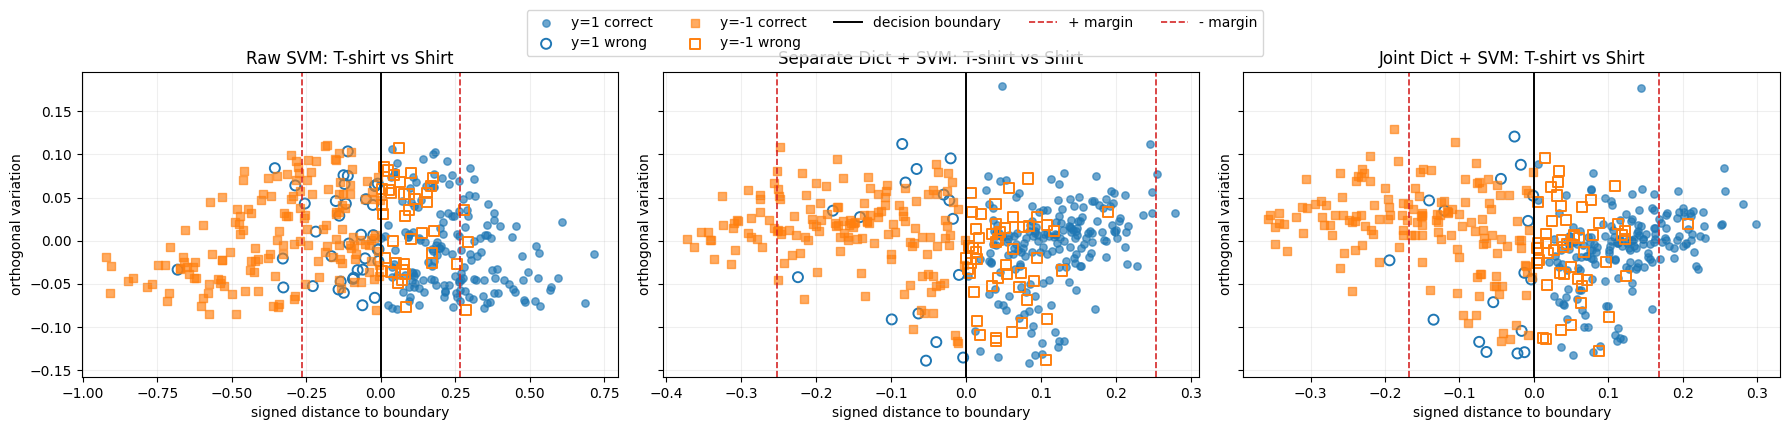

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, (method, projection) in zip(axes, margin_views.items()):
    plot_svm_margin_projection(projection, ax=ax, title=f'{method}: {explain_task.name}')
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()
plt.show()


joint selected examples: {'strong_correct': [78, 39], 'violated_correct': [160, 40], 'misclassified': [29, 180]}

=== strong_correct: sample 78 ===
field | value
index | 78
label | -1
prediction | -1
correct | True
score | -2.12755
signed_margin | 2.12755
margin_residual | -1.12755
positive_violation | 0
violated | False

atom | coeff | classifier_weight | score_contribution
31 | 0.379482 | -2.25074 | -0.854114
28 | -0.286 | 0.810196 | -0.231716
6 | 0.283114 | -1.86975 | -0.529353
23 | -0.208602 | 0.439324 | -0.0916438
22 | 0.20576 | -0.667708 | -0.137387
2 | 0.204436 | -1.30689 | -0.267176


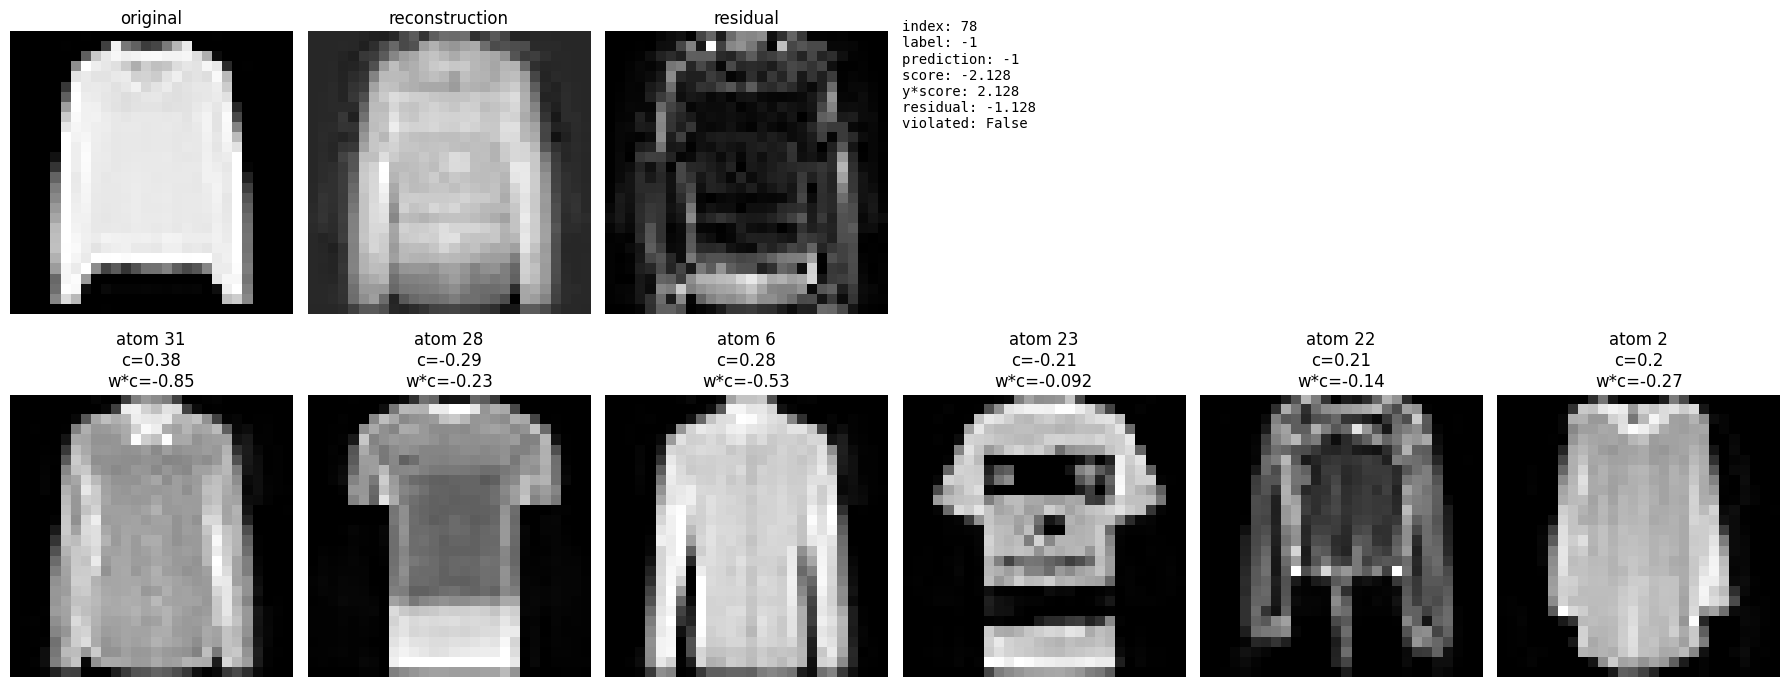


=== strong_correct: sample 39 ===
field | value
index | 39
label | -1
prediction | -1
correct | True
score | -2.11194
signed_margin | 2.11194
margin_residual | -1.11194
positive_violation | 0
violated | False

atom | coeff | classifier_weight | score_contribution
6 | 0.439903 | -1.86975 | -0.82251
31 | 0.276212 | -2.25074 | -0.621682
12 | 0.194767 | -0.296232 | -0.0576962
2 | 0.128219 | -1.30689 | -0.167569
30 | 0.0833898 | -0.480633 | -0.0400799
4 | 0.0664203 | -0.92659 | -0.0615444


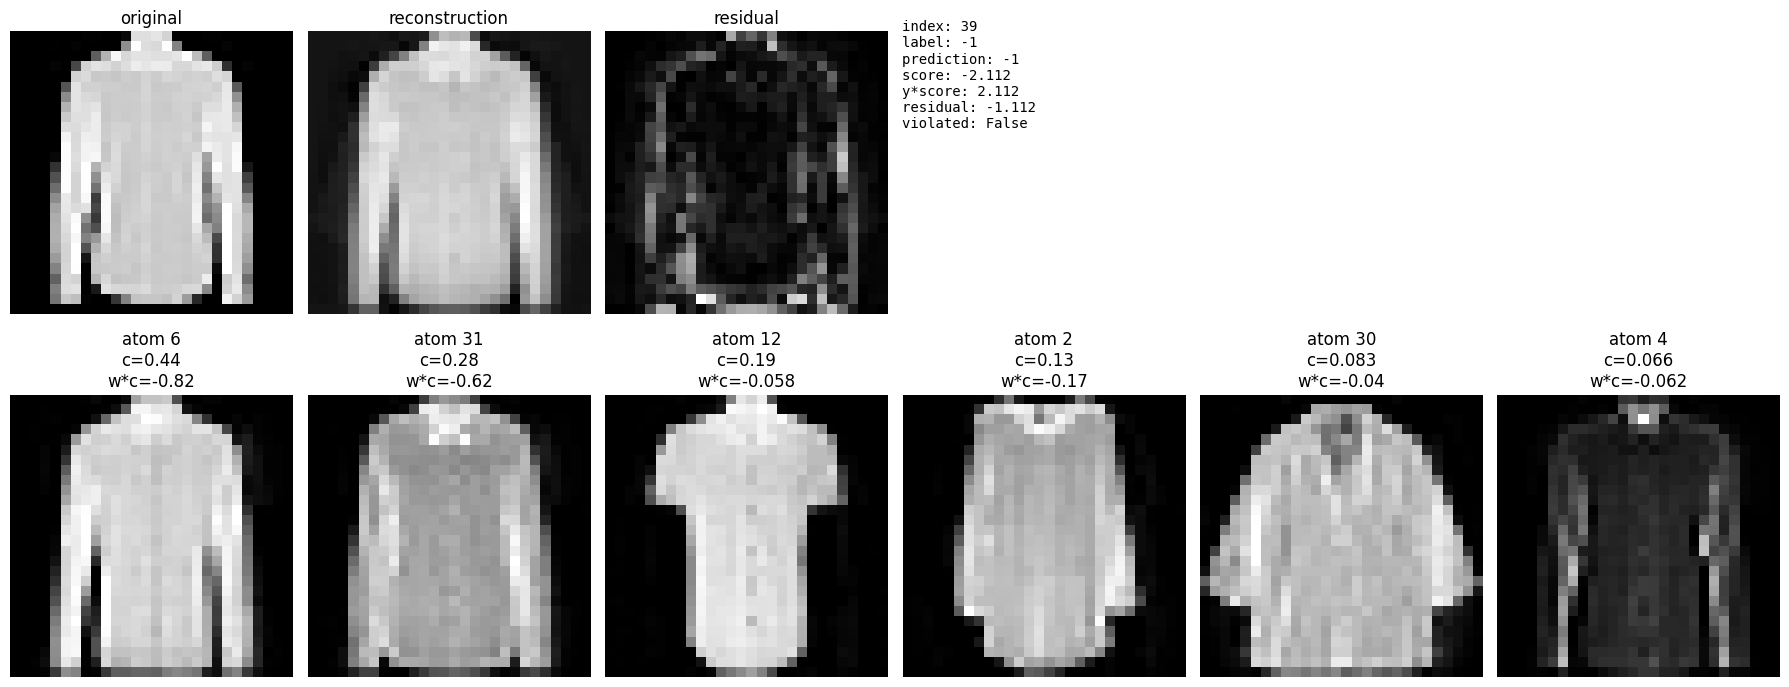


=== violated_correct: sample 160 ===
field | value
index | 160
label | -1
prediction | -1
correct | True
score | -0.00779562
signed_margin | 0.00779562
margin_residual | 0.992204
positive_violation | 0.992204
violated | True

atom | coeff | classifier_weight | score_contribution
30 | 0.22747 | -0.480633 | -0.10933
45 | 0.222986 | -0.0481939 | -0.0107466
40 | 0.217416 | 0.274875 | 0.0597621
8 | 0.185501 | -0.786291 | -0.145858
24 | 0.13513 | -0.777344 | -0.105042
19 | 0.120793 | 1.13471 | 0.137064


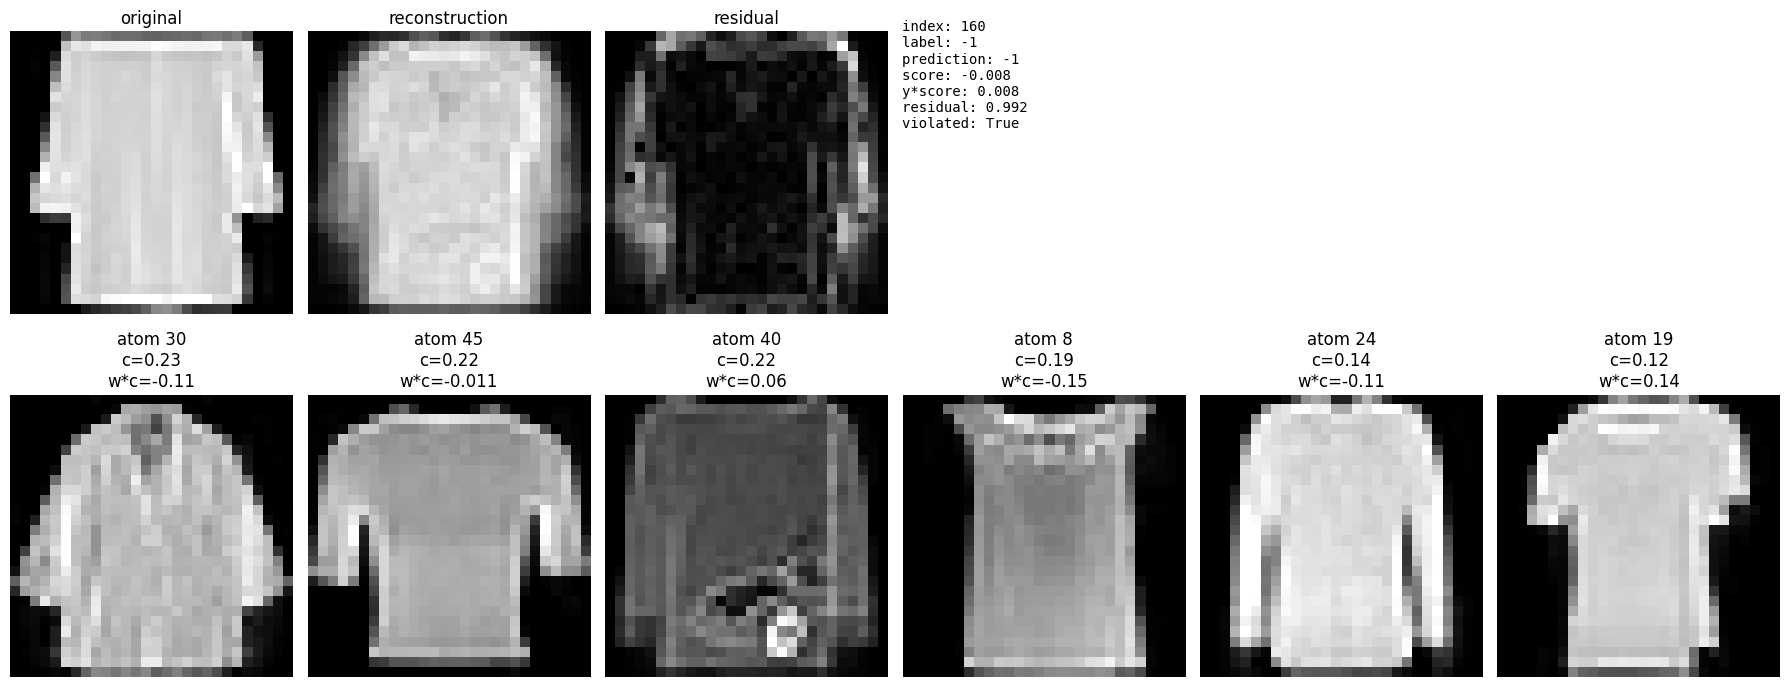


=== violated_correct: sample 40 ===
field | value
index | 40
label | -1
prediction | -1
correct | True
score | -0.0184283
signed_margin | 0.0184283
margin_residual | 0.981572
positive_violation | 0.981572
violated | True

atom | coeff | classifier_weight | score_contribution
38 | 0.115423 | -0.181769 | -0.0209804
26 | 0.0898857 | -0.698822 | -0.0628141
9 | 0.0891279 | 1.13002 | 0.100716
24 | -0.071939 | -0.777344 | 0.0559213
14 | 0.0671821 | 0.349922 | 0.0235085
47 | 0.0603692 | -0.298373 | -0.0180126


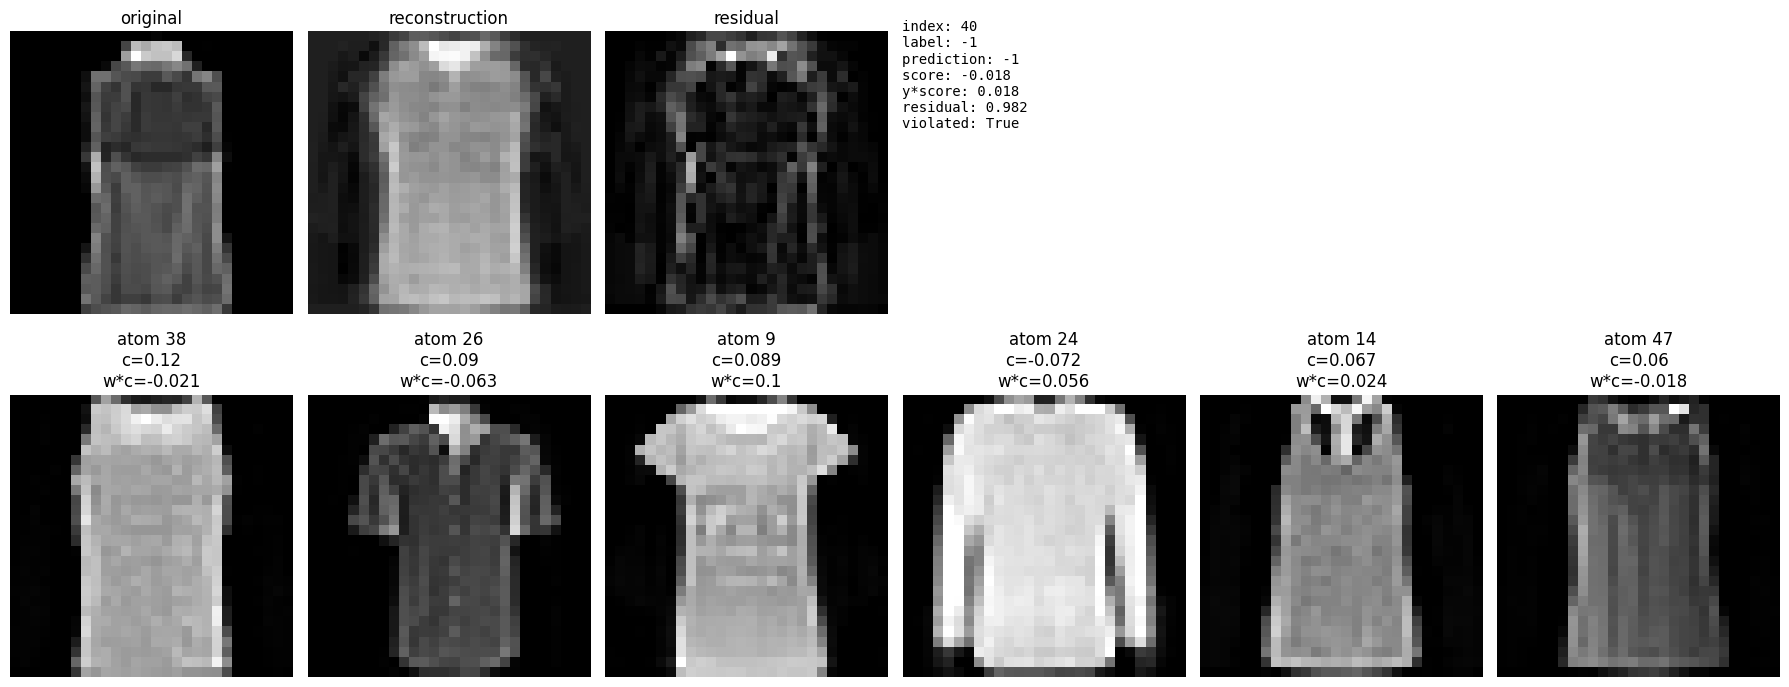


=== misclassified: sample 29 ===
field | value
index | 29
label | -1
prediction | 1
correct | False
score | 1.23191
signed_margin | -1.23191
margin_residual | 2.23191
positive_violation | 2.23191
violated | True

atom | coeff | classifier_weight | score_contribution
37 | 0.198635 | 1.21217 | 0.240779
5 | 0.186724 | 0.167667 | 0.0313075
7 | 0.171032 | 0.694817 | 0.118836
32 | 0.111921 | 1.06172 | 0.118829
19 | 0.101548 | 1.13471 | 0.115228
44 | 0.0987015 | 1.65488 | 0.163339


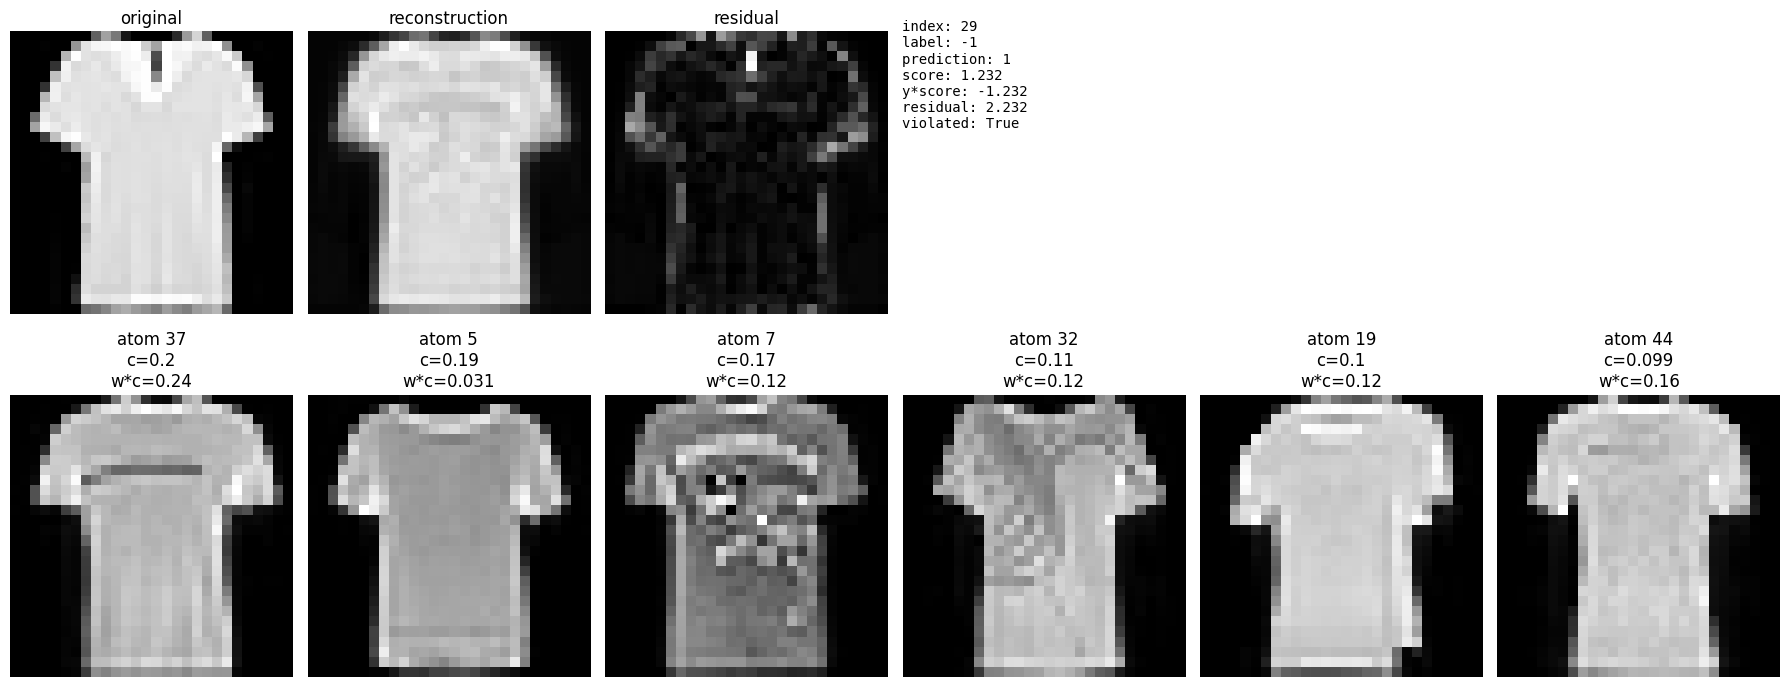


=== misclassified: sample 180 ===
field | value
index | 180
label | 1
prediction | -1
correct | False
score | -1.15445
signed_margin | -1.15445
margin_residual | 2.15445
positive_violation | 2.15445
violated | True

atom | coeff | classifier_weight | score_contribution
25 | 0.436643 | -0.349065 | -0.152417
3 | 0.276452 | -0.422404 | -0.116774
6 | 0.190067 | -1.86975 | -0.355378
14 | 0.177275 | 0.349922 | 0.0620323
31 | 0.155281 | -2.25074 | -0.349496
24 | 0.137408 | -0.777344 | -0.106813


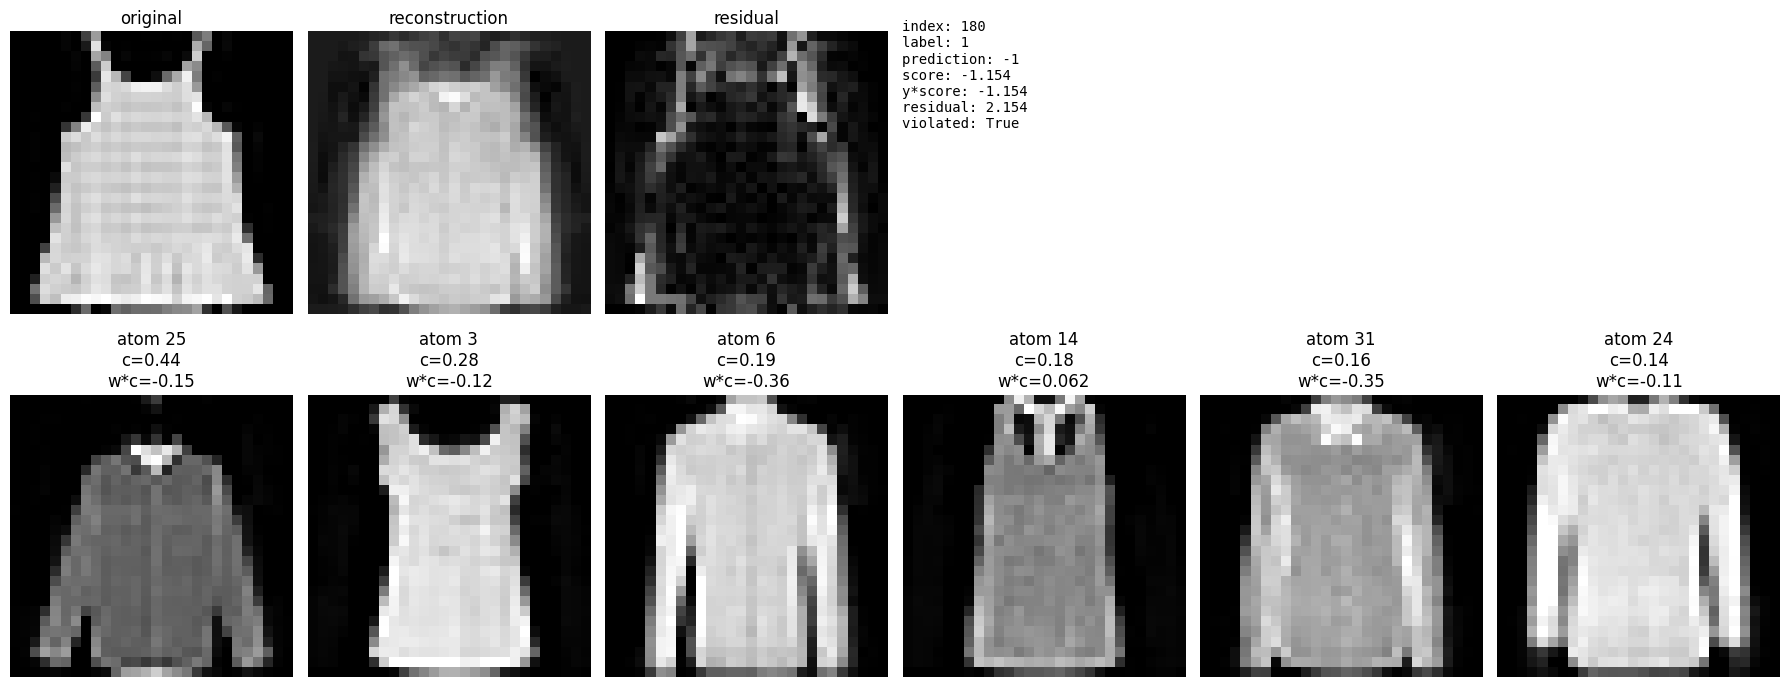

In [13]:
joint_diag_e = margin_diagnostics(joint_C_test_e, y_test_e, joint_params_e['w'], float(joint_params_e['b']))
selected_examples = select_representative_indices(joint_diag_e, max_per_group=2)
print('joint selected examples:', {key: value.tolist() for key, value in selected_examples.items()})

for group_name, indices in selected_examples.items():
    for sample_idx in indices:
        explanation = sample_explanation(
            X_test_e,
            joint_params_e['D'],
            joint_C_test_e,
            y_test_e,
            joint_params_e['w'],
            float(joint_params_e['b']),
            int(sample_idx),
            top_k=6,
        )
        print(f'\n=== {group_name}: sample {int(sample_idx)} ===')
        print(format_sample_explanation(explanation))
        plot_sample_explanation(explanation, joint_params_e['D'], top_k=6)
        plt.show()


## Meeting Notes Template

Use the cells above to fill in these points before the meeting:

- Does joint improve, match, or underperform separate dictionary learning on MNIST pairs?
- Does the behavior change on Fashion-MNIST pairs?
- Is the joint method mainly suffering from lower accuracy, larger train-test gap, or larger margin violation?
- Does joint provide a better reconstruction/sparsity trade-off even when accuracy is not higher?
- Should the next stage be systematic validation tuning, task selection, or objective modification?